In [1]:
import pandas as pd
import seaborn as sns
import pingouin as pg

comp_list = ['gamma1', 'gamma2', 'gamma3', 'gamma4', 'gamma5', 'betap2']

In [2]:
all = pd.read_csv('explant_traces.csv')
all

,Calcium,Opto,Time,Compartment,Stim_Duration,Brain,Group,Date,VNC,Exp
0,-0.004617,0,-5.000000,gamma2,200,b1,Control,240116,B-VNC,240116b1
1,0.003041,0,-4.933333,gamma2,200,b1,Control,240116,B-VNC,240116b1
2,-0.004516,0,-4.866667,gamma2,200,b1,Control,240116,B-VNC,240116b1
3,-0.013690,0,-4.800000,gamma2,200,b1,Control,240116,B-VNC,240116b1
4,0.000119,0,-4.733333,gamma2,200,b1,Control,240116,B-VNC,240116b1
...,...,...,...,...,...,...,...,...,...,...
67495,0.008886,0,4.666667,gamma5,1000,b1,Intervention,240320,B-Only,240320b1
67496,-0.015859,0,4.733333,gamma5,1000,b1,Intervention,240320,B-Only,240320b1
67497,-0.031066,0,4.800000,gamma5,1000,b1,Intervention,240320,B-Only,240320b1
67498,0.010034,0,4.866667,gamma5,1000,b1,Intervention,240320,B-Only,240320b1


# plot traces

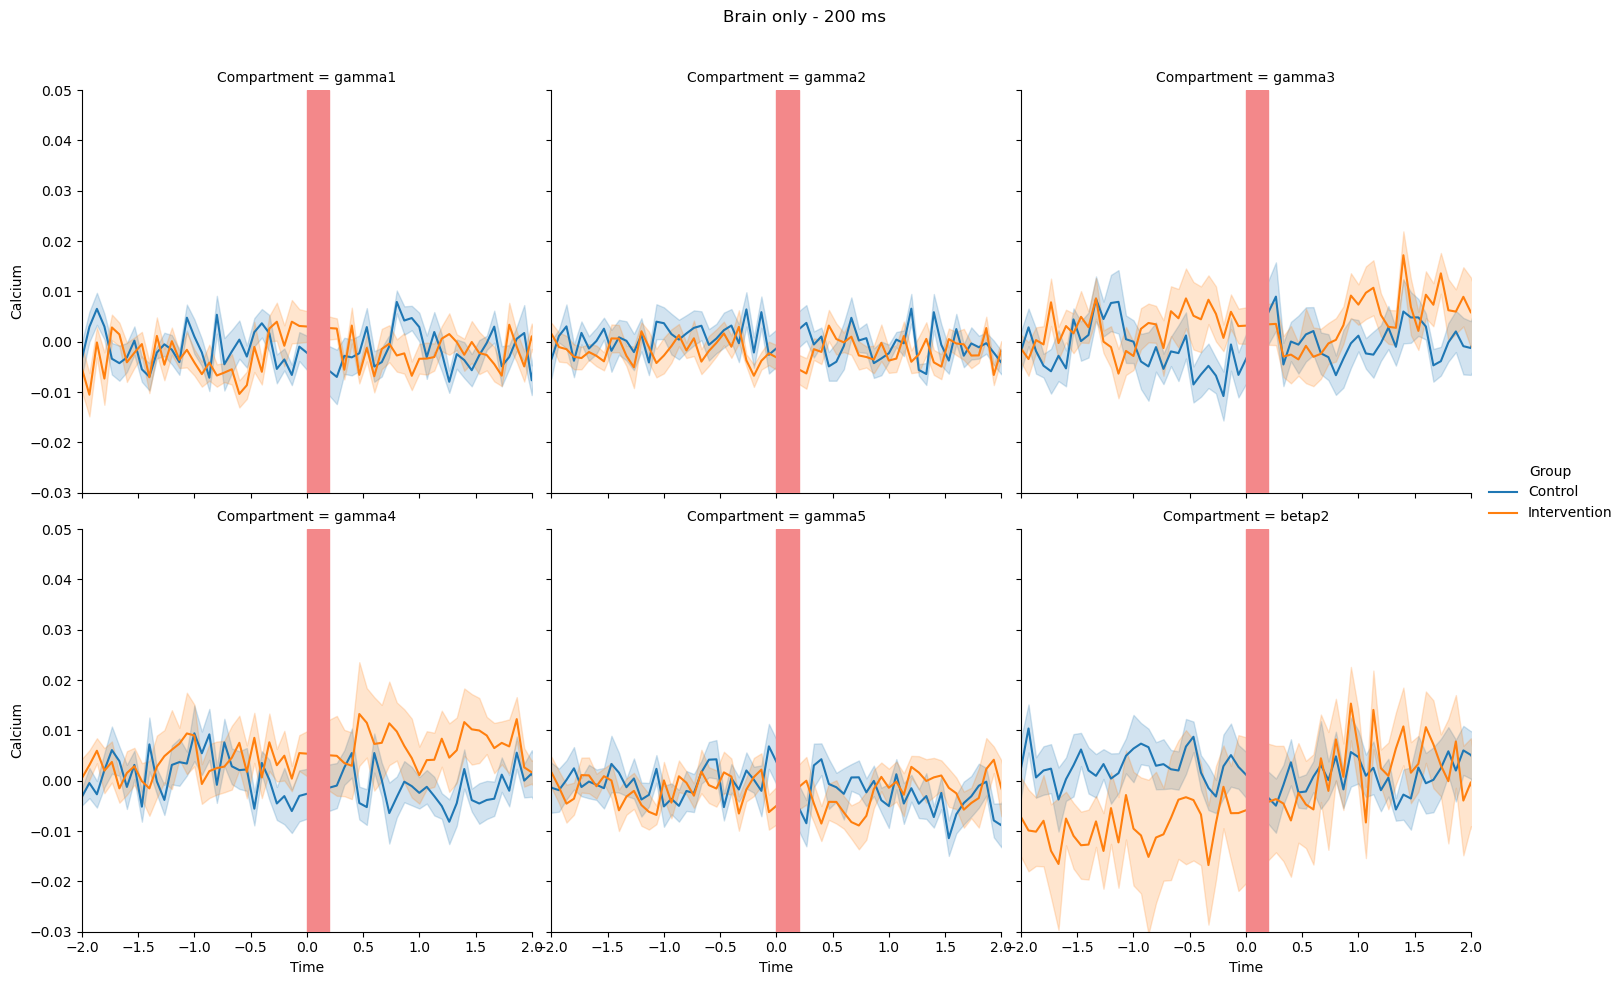

In [3]:
sns_plot = sns.relplot(data=all.loc[(all.VNC=='B-Only')&(all.Stim_Duration==200)], 
                       x='Time', kind='line', y='Calcium', col='Compartment',
            col_wrap=3, errorbar='se', hue='Group', col_order=comp_list)

sns_plot.fig.subplots_adjust(top=0.9)
sns_plot.fig.suptitle('Brain only - 200 ms')

for ax in sns_plot.axes.flat:
    ax.set_xlim([-2, 2])
    ax.axvspan(0, 0.2, color='#f3888a', alpha=1.0, zorder=10)
    ax.set_ylim([-0.03, 0.05])

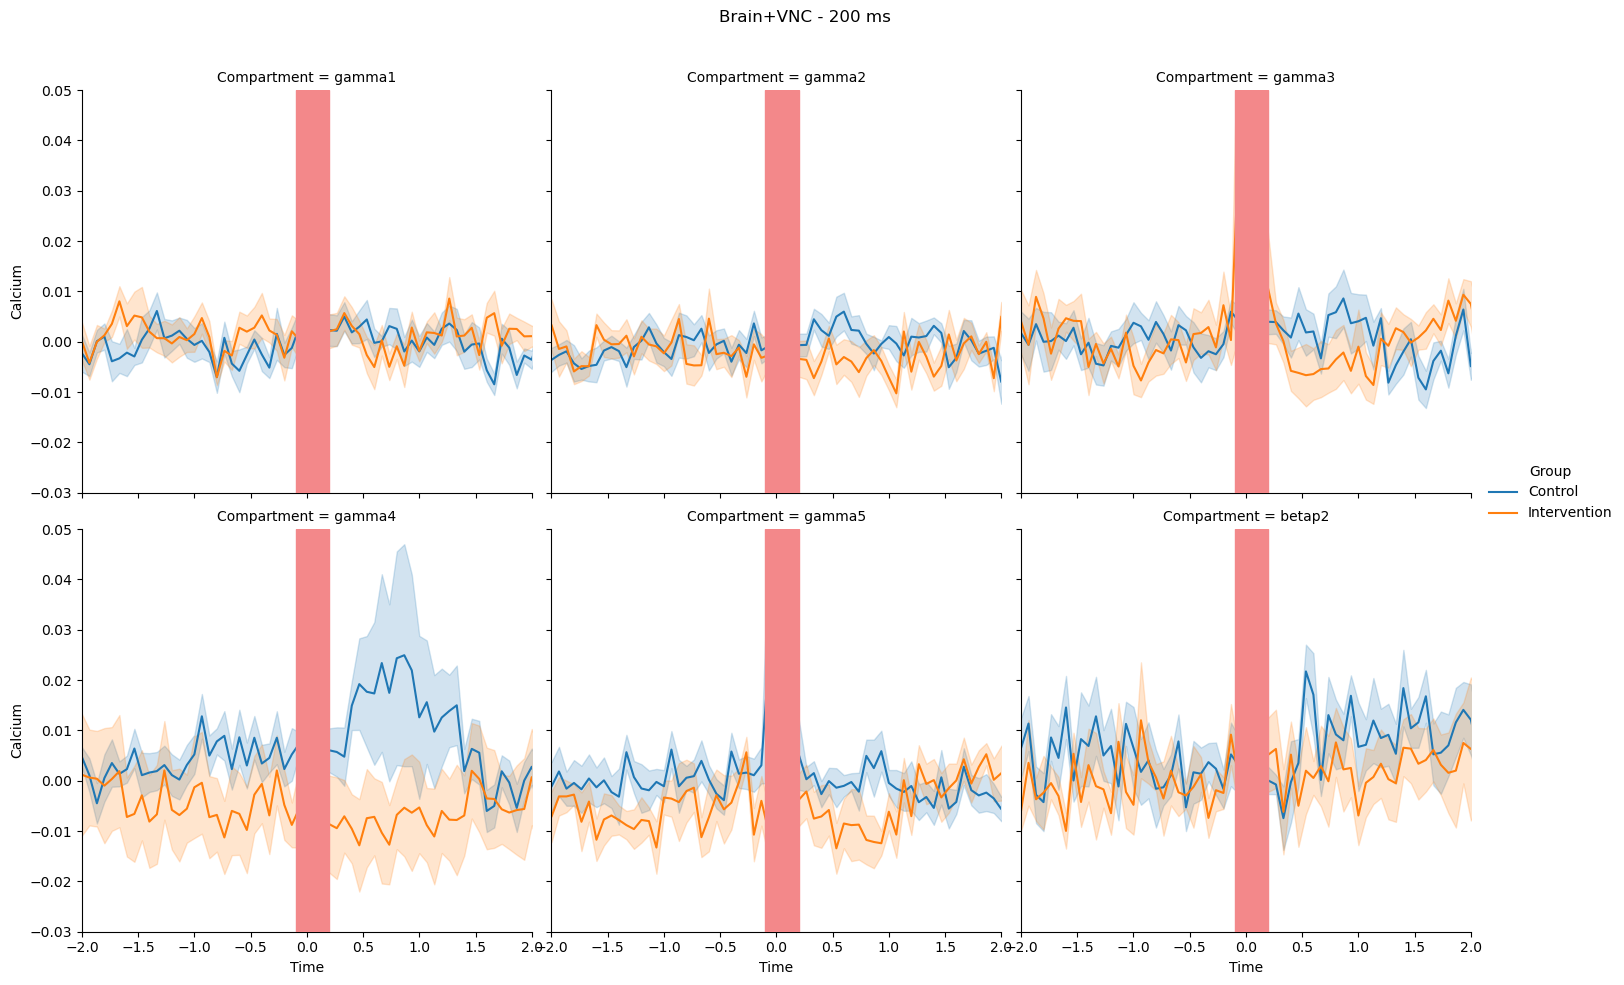

In [4]:
sns_plot = sns.relplot(data=all.loc[(all.VNC=='B-VNC')&(all.Stim_Duration==200)], 
                       x='Time', kind='line', y='Calcium', col='Compartment',
            col_wrap=3, errorbar='se', hue='Group', col_order=comp_list)

sns_plot.fig.subplots_adjust(top=0.9)
sns_plot.fig.suptitle('Brain+VNC - 200 ms')

for ax in sns_plot.axes.flat:
    ax.set_xlim([-2, 2])
    ax.axvspan(-0.1, 0.2, color='#f3888a', alpha=1.0, zorder=10)
    ax.set_ylim([-0.03, 0.05])

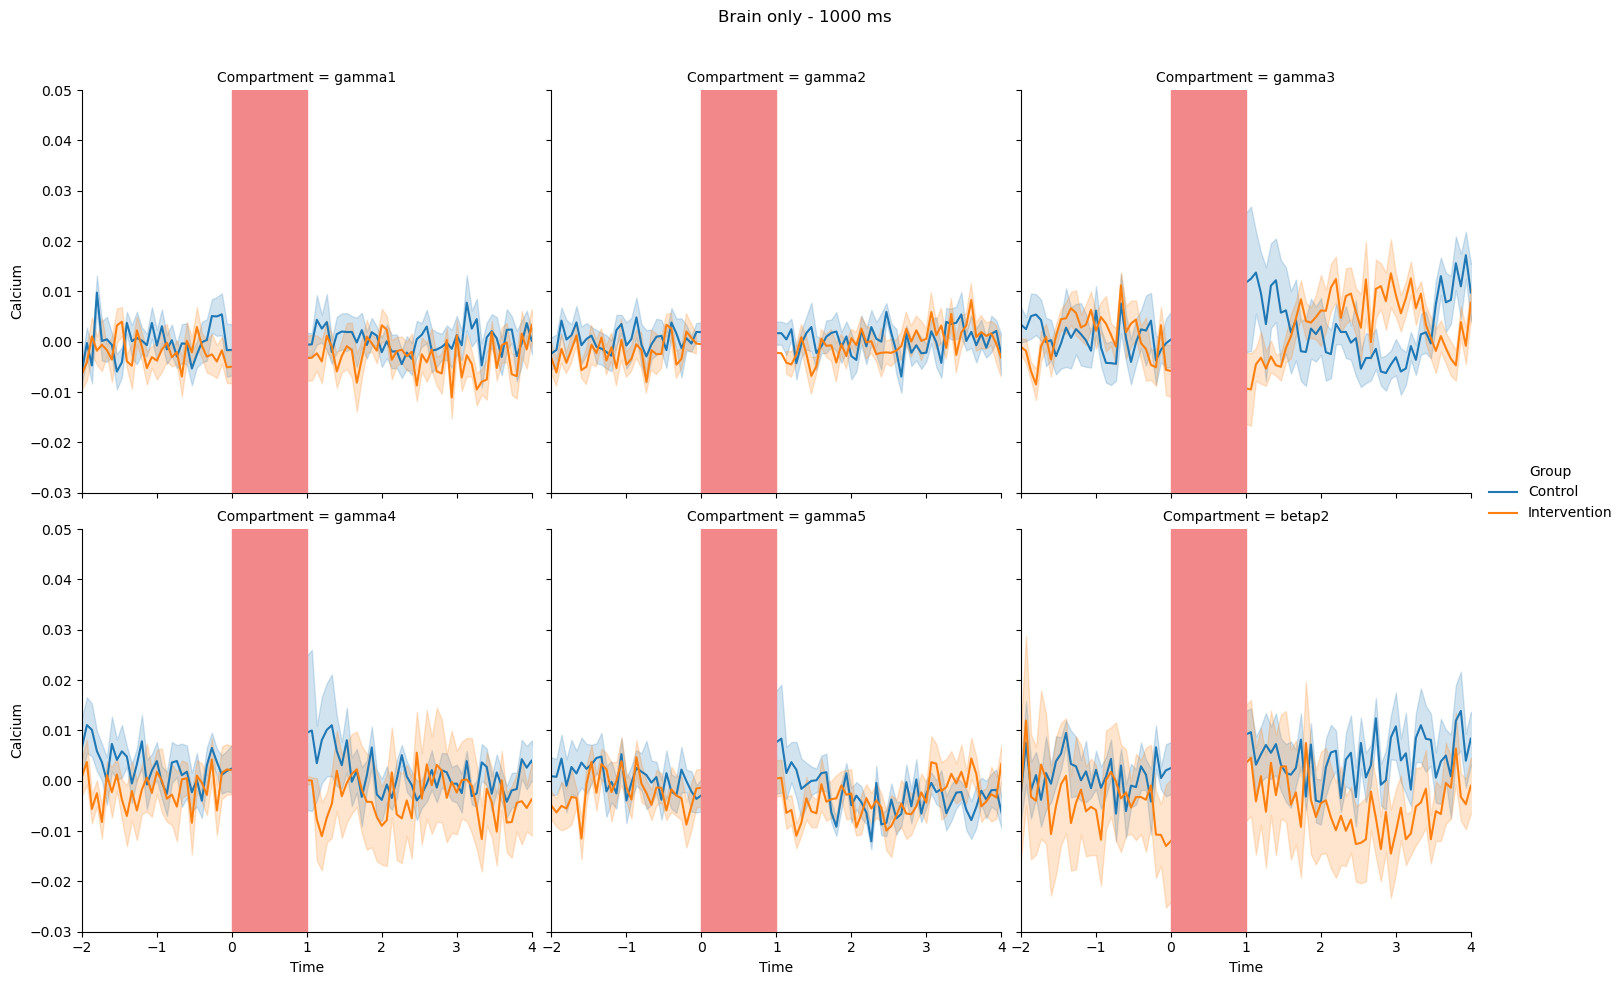

In [5]:
sns_plot = sns.relplot(data=all.loc[(all.VNC=='B-Only')&(all.Stim_Duration==1000)], 
                       x='Time', kind='line', y='Calcium', col='Compartment',
            col_wrap=3, errorbar='se', hue='Group', col_order=comp_list)

sns_plot.fig.subplots_adjust(top=0.9)
sns_plot.fig.suptitle('Brain only - 1000 ms')

for ax in sns_plot.axes.flat:
    ax.set_xlim([-2, 4])
    ax.axvspan(0, 1, color='#f3888a', alpha=1.0, zorder=10)
    ax.set_ylim([-0.03, 0.05])

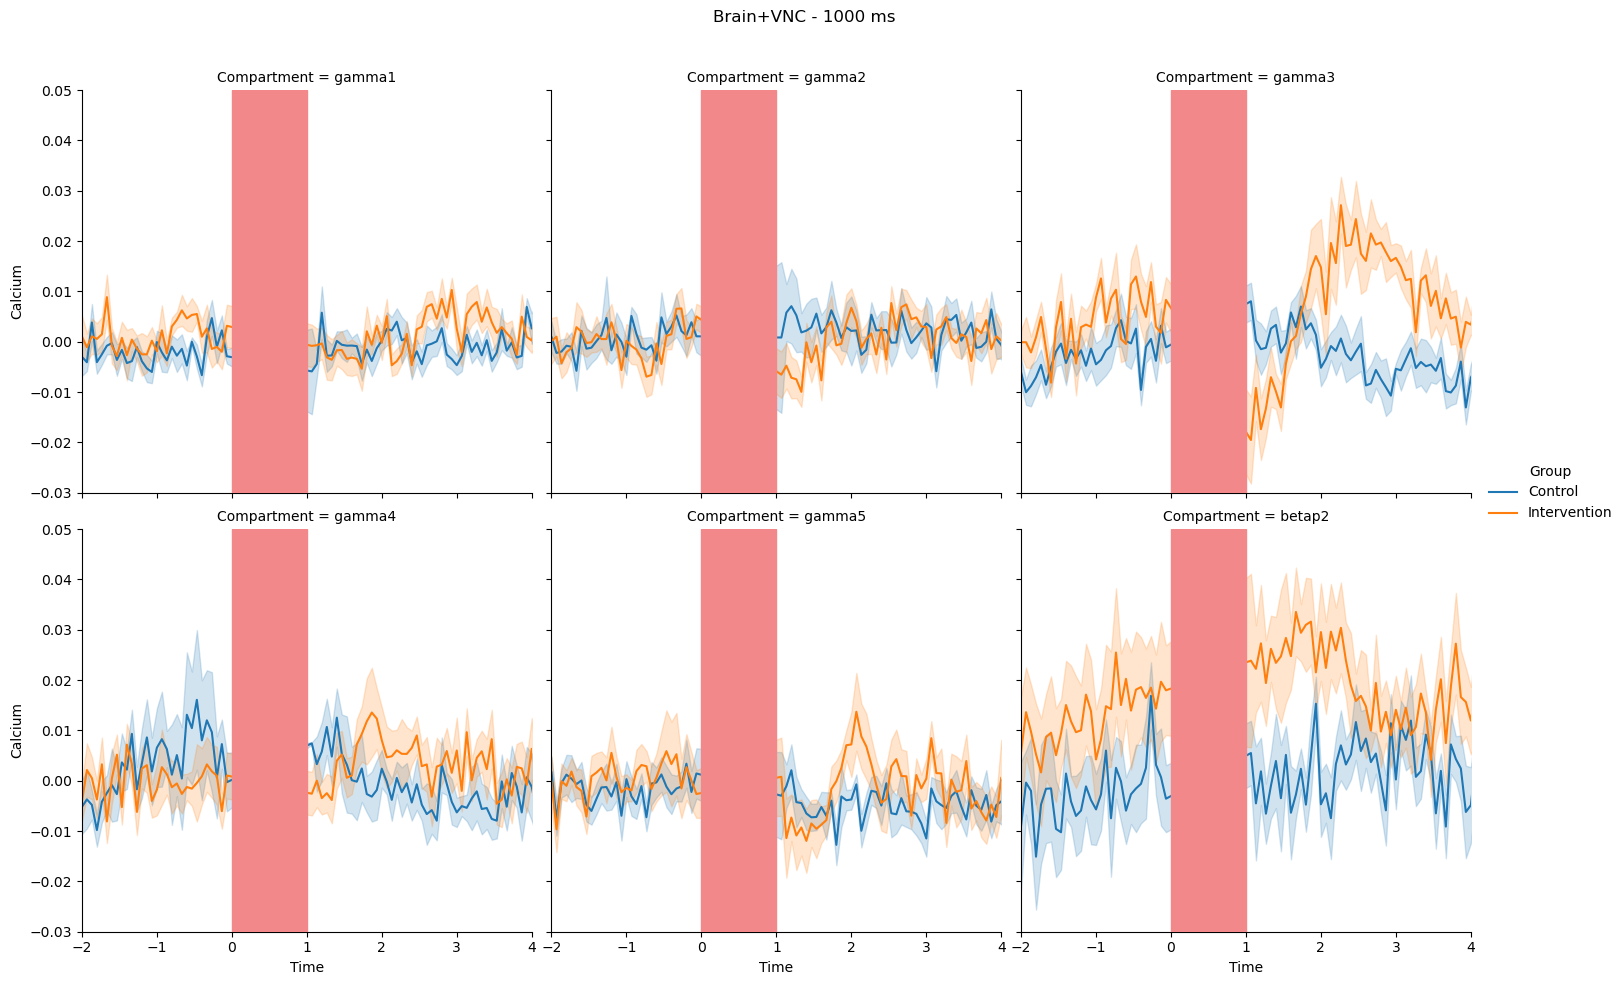

In [6]:
sns_plot = sns.relplot(data=all.loc[(all.VNC=='B-VNC')&(all.Stim_Duration==1000)], 
                       x='Time', kind='line', y='Calcium', col='Compartment',
            col_wrap=3, errorbar='se', hue='Group', col_order=comp_list)

sns_plot.fig.subplots_adjust(top=0.9)
sns_plot.fig.suptitle('Brain+VNC - 1000 ms')

for ax in sns_plot.axes.flat:
    ax.set_xlim([-2, 4])
    ax.axvspan(0, 1, color='#f3888a', alpha=1.0, zorder=10)
    ax.set_ylim([-0.03, 0.05])

# stats 2s pre vs 2s post

In [7]:
all.loc[(all.Time>-2)&(all.Time<0), 'prepost'] = 'pre'
all.loc[((all.Time>0.2)&(all.Time<2.2)&(all.Stim_Duration==200))|\
        ((all.Time>1)&(all.Time<3)&(all.Stim_Duration==1000)), 'prepost'] = 'post'
all

,Calcium,Opto,Time,Compartment,Stim_Duration,Brain,Group,Date,VNC,Exp,prepost
0,-0.004617,0,-5.000000,gamma2,200,b1,Control,240116,B-VNC,240116b1,NaN
1,0.003041,0,-4.933333,gamma2,200,b1,Control,240116,B-VNC,240116b1,NaN
2,-0.004516,0,-4.866667,gamma2,200,b1,Control,240116,B-VNC,240116b1,NaN
3,-0.013690,0,-4.800000,gamma2,200,b1,Control,240116,B-VNC,240116b1,NaN
4,0.000119,0,-4.733333,gamma2,200,b1,Control,240116,B-VNC,240116b1,NaN
...,...,...,...,...,...,...,...,...,...,...,...
67495,0.008886,0,4.666667,gamma5,1000,b1,Intervention,240320,B-Only,240320b1,NaN
67496,-0.015859,0,4.733333,gamma5,1000,b1,Intervention,240320,B-Only,240320b1,NaN
67497,-0.031066,0,4.800000,gamma5,1000,b1,Intervention,240320,B-Only,240320b1,NaN
67498,0.010034,0,4.866667,gamma5,1000,b1,Intervention,240320,B-Only,240320b1,NaN


In [8]:
prepost = all.dropna().groupby(['Exp','VNC', 'Group', 'Stim_Duration', 'Compartment', 'prepost'])\
    .agg({'Calcium': 'mean'}).reset_index()
prepost_diff = prepost.loc[prepost.prepost=='post'].reset_index(drop=True)
prepost_diff['Calcium'] = prepost_diff['Calcium'] - prepost.loc[prepost.prepost=='pre', 'Calcium'].reset_index(drop=True)
prepost_diff

,Exp,VNC,Group,Stim_Duration,Compartment,prepost,Calcium
0,231219b1,B-Only,Control,200,betap2,post,-0.000750
1,231219b1,B-Only,Control,200,gamma1,post,-0.002784
2,231219b1,B-Only,Control,200,gamma2,post,-0.006325
3,231219b1,B-Only,Control,200,gamma3,post,-0.001096
4,231219b1,B-Only,Control,200,gamma4,post,-0.001096
...,...,...,...,...,...,...,...
442,240322b3,B-Only,Intervention,1000,gamma1,post,-0.004253
443,240322b3,B-Only,Intervention,1000,gamma2,post,-0.001727
444,240322b3,B-Only,Intervention,1000,gamma3,post,0.006327
445,240322b3,B-Only,Intervention,1000,gamma4,post,0.014625


Text(0.5, 0.98, '∆ 2sec post - 2sec pre stim')

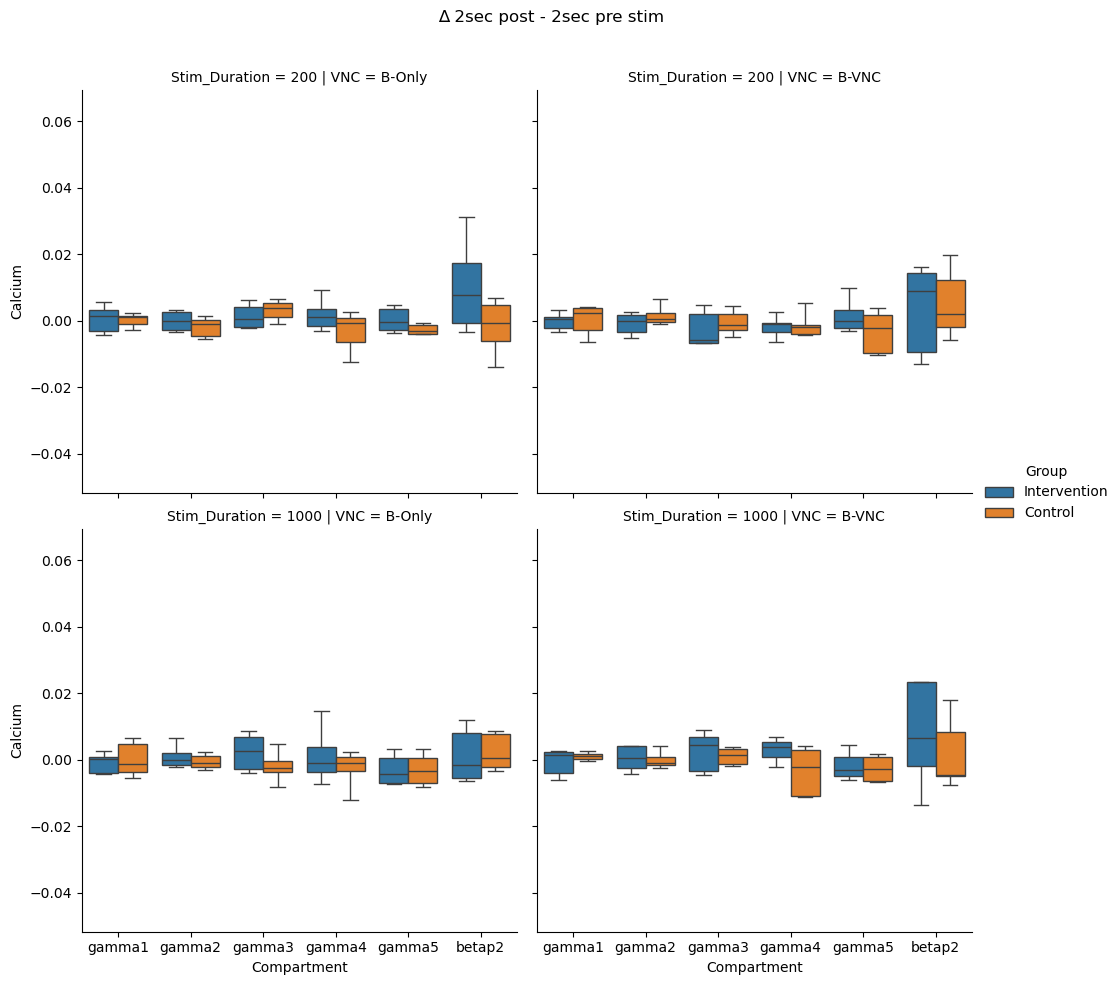

In [9]:
sns_plot = sns.catplot(kind='box', data=prepost_diff, col='VNC', 
            y='Calcium', hue='Group', x='Compartment', row='Stim_Duration', order=comp_list, whis=(10, 90), fliersize=0,
            row_order=[200, 1000], hue_order=['Intervention', 'Control'])

sns_plot.fig.subplots_adjust(top=0.9)
sns_plot.fig.suptitle('∆ 2sec post - 2sec pre stim')

In [10]:
# B-only 200 ms

pvals = []
for comp in comp_list:
    pvals.append(pg.pairwise_tests(prepost_diff.loc[(prepost_diff.Compartment==comp)&
                                                    (prepost_diff.VNC=='B-Only')&
                                                    (prepost_diff.Stim_Duration==200)], 
                                   dv='Calcium', between='Group',
                               subject='Exp', parametric=False)['p-unc'].values[0])
pd.DataFrame(pg.multicomp(pvals, method='holm'), columns=comp_list)

,gamma1,gamma2,gamma3,gamma4,gamma5,betap2
0,False,False,False,False,False,False
1,1.0,1.0,1.0,0.743507,0.444865,0.382139


In [11]:
# B-only 1000 ms

pvals = []
for comp in comp_list:
    pvals.append(pg.pairwise_tests(prepost_diff.loc[(prepost_diff.Compartment==comp)&
                                                    (prepost_diff.VNC=='B-Only')&
                                                    (prepost_diff.Stim_Duration==1000)], 
                                   dv='Calcium', between='Group',
                               subject='Exp', parametric=False)['p-unc'].values[0])
pd.DataFrame(pg.multicomp(pvals, method='holm'), columns=comp_list)

,gamma1,gamma2,gamma3,gamma4,gamma5,betap2
0,False,False,False,False,False,False
1,1.0,1.0,1.0,1.0,1.0,1.0


In [12]:
# B+VNC 200 ms

pvals = []
for comp in comp_list:
    pvals.append(pg.pairwise_tests(prepost_diff.loc[(prepost_diff.Compartment==comp)&
                                                    (prepost_diff.VNC=='B-VNC')&
                                                    (prepost_diff.Stim_Duration==200)], 
                                   dv='Calcium', between='Group',
                               subject='Exp', parametric=False)['p-unc'].values[0])
pd.DataFrame(pg.multicomp(pvals, method='holm'), columns=comp_list)

,gamma1,gamma2,gamma3,gamma4,gamma5,betap2
0,False,False,False,False,False,False
1,1.0,1.0,1.0,1.0,1.0,1.0


In [13]:
# B+VNC 1000 ms

pvals = []
for comp in comp_list:
    pvals.append(pg.pairwise_tests(prepost_diff.loc[(prepost_diff.Compartment==comp)&
                                                    (prepost_diff.VNC=='B-VNC')&
                                                    (prepost_diff.Stim_Duration==1000)], 
                                   dv='Calcium', between='Group',
                               subject='Exp', parametric=False)['p-unc'].values[0])
pd.DataFrame(pg.multicomp(pvals, method='holm'), columns=comp_list)

,gamma1,gamma2,gamma3,gamma4,gamma5,betap2
0,False,False,False,False,False,False
1,1.0,1.0,1.0,0.832744,1.0,1.0


# stats 2s pre vs 0.5s post

In [14]:
all.loc[(all.Time>-2)&(all.Time<0), 'prepost2'] = 'pre'
all.loc[((all.Time>0.2)&(all.Time<0.7)&(all.Stim_Duration==200))|\
        ((all.Time>1)&(all.Time<1.5)&(all.Stim_Duration==1000)), 'prepost2'] = 'post'
all

,Calcium,Opto,Time,Compartment,Stim_Duration,Brain,Group,Date,VNC,Exp,prepost,prepost2
0,-0.004617,0,-5.000000,gamma2,200,b1,Control,240116,B-VNC,240116b1,NaN,NaN
1,0.003041,0,-4.933333,gamma2,200,b1,Control,240116,B-VNC,240116b1,NaN,NaN
2,-0.004516,0,-4.866667,gamma2,200,b1,Control,240116,B-VNC,240116b1,NaN,NaN
3,-0.013690,0,-4.800000,gamma2,200,b1,Control,240116,B-VNC,240116b1,NaN,NaN
4,0.000119,0,-4.733333,gamma2,200,b1,Control,240116,B-VNC,240116b1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
67495,0.008886,0,4.666667,gamma5,1000,b1,Intervention,240320,B-Only,240320b1,NaN,NaN
67496,-0.015859,0,4.733333,gamma5,1000,b1,Intervention,240320,B-Only,240320b1,NaN,NaN
67497,-0.031066,0,4.800000,gamma5,1000,b1,Intervention,240320,B-Only,240320b1,NaN,NaN
67498,0.010034,0,4.866667,gamma5,1000,b1,Intervention,240320,B-Only,240320b1,NaN,NaN


In [15]:
prepost2 = all.dropna().groupby(['Exp','VNC', 'Group', 'Stim_Duration', 'Compartment', 'prepost2'])\
    .agg({'Calcium': 'mean'}).reset_index()
prepost2_diff = prepost2.loc[prepost2.prepost2=='post'].reset_index(drop=True)
prepost2_diff['Calcium'] = prepost2_diff['Calcium'] - prepost2.loc[prepost2.prepost2=='pre', 'Calcium'].reset_index(drop=True)
prepost2_diff

,Exp,VNC,Group,Stim_Duration,Compartment,prepost2,Calcium
0,231219b1,B-Only,Control,200,betap2,post,-0.003584
1,231219b1,B-Only,Control,200,gamma1,post,-0.005577
2,231219b1,B-Only,Control,200,gamma2,post,-0.006520
3,231219b1,B-Only,Control,200,gamma3,post,-0.003630
4,231219b1,B-Only,Control,200,gamma4,post,-0.003630
...,...,...,...,...,...,...,...
442,240322b3,B-Only,Intervention,1000,gamma1,post,-0.002360
443,240322b3,B-Only,Intervention,1000,gamma2,post,-0.005570
444,240322b3,B-Only,Intervention,1000,gamma3,post,-0.008076
445,240322b3,B-Only,Intervention,1000,gamma4,post,0.005400


In [16]:
prepost2_diff.to_clipboard()

Text(0.5, 0.98, '∆ 0.5sec post - 2sec pre stim')

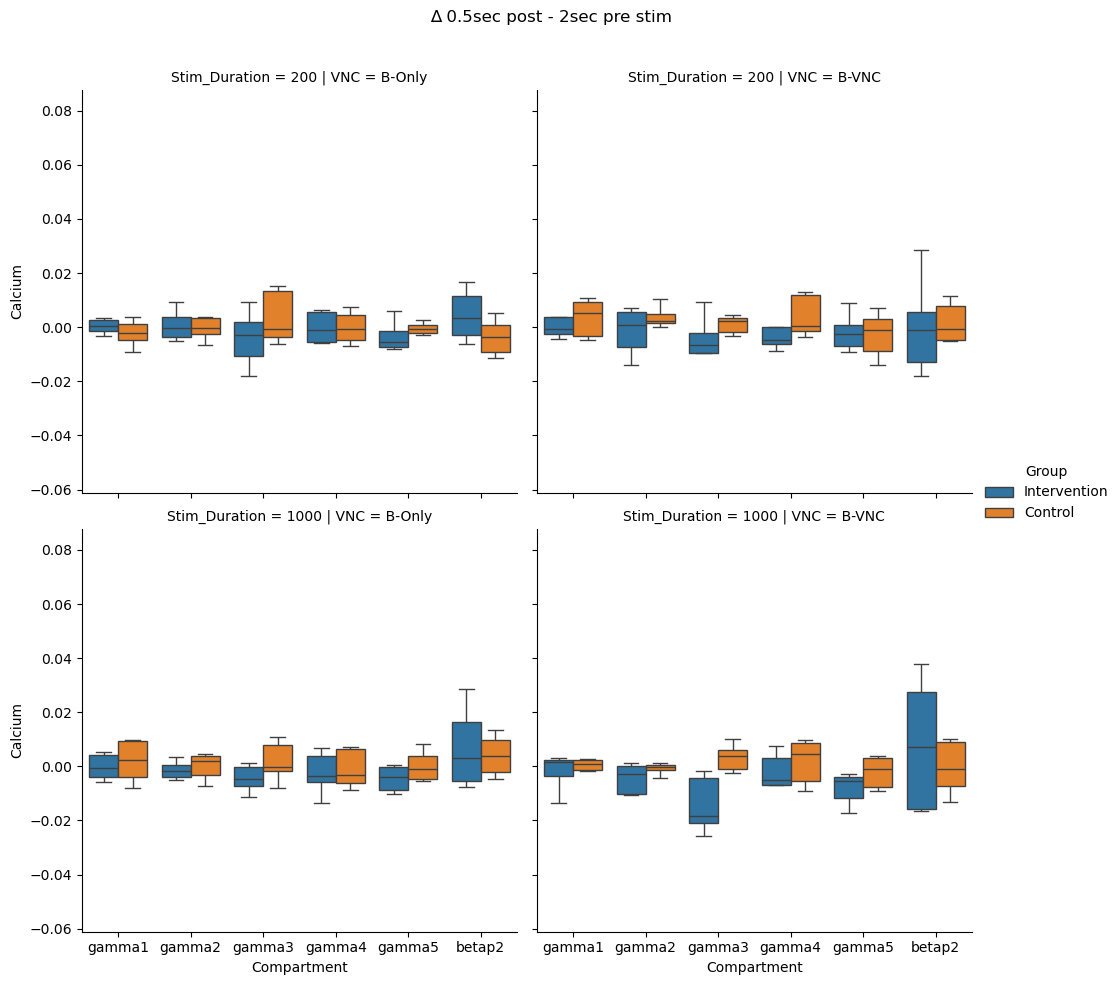

In [17]:
sns_plot = sns.catplot(kind='box', data=prepost2_diff, col='VNC', 
            y='Calcium', hue='Group', x='Compartment', row='Stim_Duration', order=comp_list, whis=(10, 90), fliersize=0,
            row_order=[200, 1000], hue_order=['Intervention', 'Control'])

sns_plot.fig.subplots_adjust(top=0.9)
sns_plot.fig.suptitle('∆ 0.5sec post - 2sec pre stim')


In [18]:
# B-only 200 ms

pvals = []
for comp in comp_list:
    pvals.append(pg.pairwise_tests(prepost2_diff.loc[(prepost2_diff.Compartment==comp)&
                                                    (prepost2_diff.VNC=='B-Only')&
                                                    (prepost2_diff.Stim_Duration==200)], 
                                   dv='Calcium', between='Group',
                               subject='Exp', parametric=False)['p-unc'].values[0])
pd.DataFrame(pg.multicomp(pvals, method='holm'), columns=comp_list)

,gamma1,gamma2,gamma3,gamma4,gamma5,betap2
0,False,False,False,False,False,False
1,1.0,1.0,1.0,1.0,0.384133,0.466988


In [19]:
# B-only 1000 ms

pvals = []
for comp in comp_list:
    pvals.append(pg.pairwise_tests(prepost2_diff.loc[(prepost2_diff.Compartment==comp)&
                                                    (prepost2_diff.VNC=='B-Only')&
                                                    (prepost2_diff.Stim_Duration==1000)], 
                                   dv='Calcium', between='Group',
                               subject='Exp', parametric=False)['p-unc'].values[0])
pd.DataFrame(pg.multicomp(pvals, method='holm'), columns=comp_list)

,gamma1,gamma2,gamma3,gamma4,gamma5,betap2
0,False,False,False,False,False,False
1,1.0,1.0,0.624659,1.0,0.929384,1.0


In [20]:
# B+VNC 200 ms

pvals = []
for comp in comp_list:
    pvals.append(pg.pairwise_tests(prepost2_diff.loc[(prepost2_diff.Compartment==comp)&
                                                    (prepost2_diff.VNC=='B-VNC')&
                                                    (prepost2_diff.Stim_Duration==200)], 
                                   dv='Calcium', between='Group',
                               subject='Exp', parametric=False)['p-unc'].values[0])
pd.DataFrame(pg.multicomp(pvals, method='holm'), columns=comp_list)

,gamma1,gamma2,gamma3,gamma4,gamma5,betap2
0,False,False,False,False,False,False
1,1.0,1.0,0.466988,0.253561,1.0,1.0


In [21]:
# B+VNC 1000 ms

pvals = []
for comp in comp_list:
    pvals.append(pg.pairwise_tests(prepost2_diff.loc[(prepost2_diff.Compartment==comp)&
                                                    (prepost2_diff.VNC=='B-VNC')&
                                                    (prepost2_diff.Stim_Duration==1000)], 
                                   dv='Calcium', between='Group',
                               subject='Exp', parametric=False)['p-unc'].values[0])
pd.DataFrame(pg.multicomp(pvals, method='holm'), columns=comp_list)

,gamma1,gamma2,gamma3,gamma4,gamma5,betap2
0,False,False,True,False,False,False
1,1.0,0.865492,0.021412,1.0,0.83587,1.0
